In [ ]:
from google.colab import files

uploaded = files.upload()

Saving archive.zip to archive (1).zip


In [ ]:
import pandas as pd
import zipfile

# Unzip the uploaded archive to extract day.csv
with zipfile.ZipFile('archive (1).zip', 'r') as zip_ref:
    zip_ref.extractall('.')

df = pd.read_csv("day.csv")

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [ ]:
print("Missing values in each column:")
print(df.isnull().sum())

Missing values in each column:
instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64


In [ ]:
print("\nTotal missing values:", df.isnull().sum().sum())


Total missing values: 0


In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv("day.csv")

# Remove unnecessary columns
# instant = ID
# casual and registered = data leakage because casual + registered = cnt
df = df.drop(columns=["instant", "casual", "registered"])

# Convert date column
df["dteday"] = pd.to_datetime(df["dteday"], dayfirst=True)

# Remove date column after conversion
df = df.drop(columns=["dteday"])

# Check missing values
print("Missing values:")
print(df.isnull().sum())

print("\nCleaned Dataset:")
display(df.head())

Missing values:
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
cnt           0
dtype: int64

Cleaned Dataset:


,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,cnt
0,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,985
1,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,801
2,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,1349
3,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,1562
4,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,1600


In [ ]:
# Categorical columns
categorical_columns = [
    "season",
    "mnth",
    "weekday",
    "weathersit"
]

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

print("Encoded Features:")
display(df.head())

Encoded Features:


,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
0,0,0,0,14.110847,18.18125,80.5833,10.749882,985,False,False,...,False,False,False,False,False,False,False,True,True,False
1,0,0,0,14.902598,17.68695,69.6087,16.652113,801,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,False,False,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
print("Final Dataset Shape:", df.shape)

print("\nFinal Dataset Columns:")
print(df.columns.tolist())

print("\nFinal Dataset:")
display(df.head())

Final Dataset Shape: (730, 30)

Final Dataset Columns:
['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'cnt', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3']

Final Dataset:


,yr,holiday,workingday,temp,atemp,hum,windspeed,cnt,season_2,season_3,...,mnth_11,mnth_12,weekday_1,weekday_2,weekday_3,weekday_4,weekday_5,weekday_6,weathersit_2,weathersit_3
0,0,0,0,14.110847,18.18125,80.5833,10.749882,985,False,False,...,False,False,False,False,False,False,False,True,True,False
1,0,0,0,14.902598,17.68695,69.6087,16.652113,801,False,False,...,False,False,False,False,False,False,False,False,True,False
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,False,False,...,False,False,True,False,False,False,False,False,False,False
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,False,False,...,False,False,False,True,False,False,False,False,False,False
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,False,False,...,False,False,False,False,True,False,False,False,False,False


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("day.csv")

df["dteday"] = pd.to_datetime(df["dteday"], dayfirst=True)

df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2018-01-01,1,0,1,0,6,0,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,2018-01-02,1,0,1,0,0,0,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,2018-01-03,1,0,1,0,1,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,2018-01-04,1,0,1,0,2,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,2018-01-05,1,0,1,0,3,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


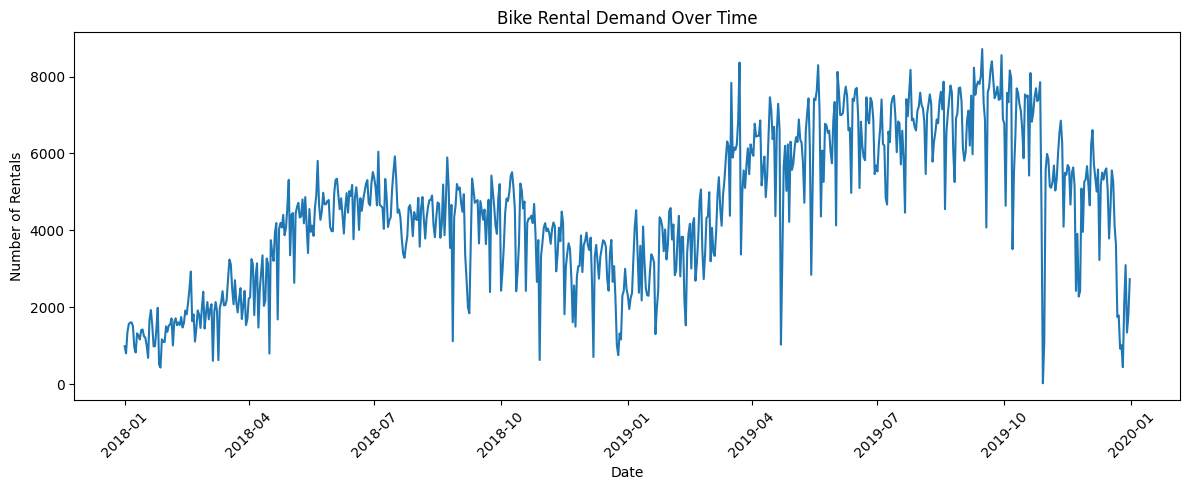

In [ ]:
plt.figure(figsize=(12, 5))

plt.plot(df["dteday"], df["cnt"])

plt.title("Bike Rental Demand Over Time")
plt.xlabel("Date")
plt.ylabel("Number of Rentals")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

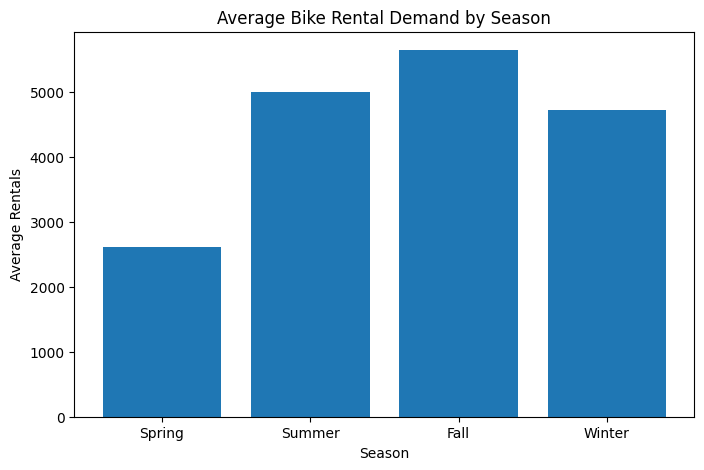

In [ ]:
season_demand = df.groupby("season")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Spring", "Summer", "Fall", "Winter"],
    season_demand.values
)

plt.title("Average Bike Rental Demand by Season")
plt.xlabel("Season")
plt.ylabel("Average Rentals")

plt.show()

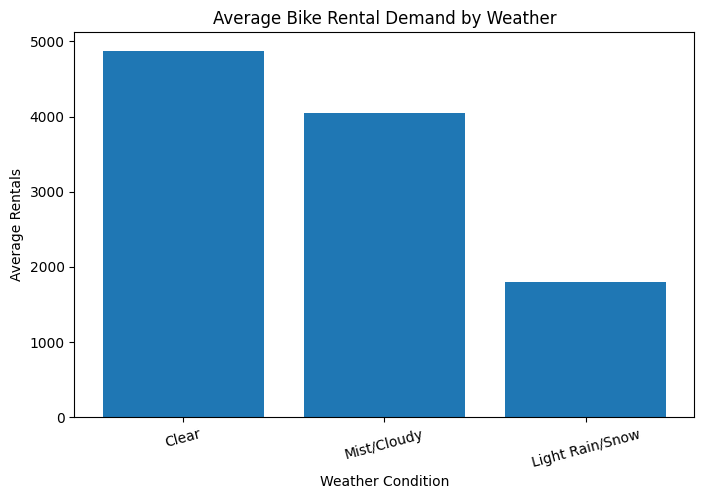

In [ ]:
weather_demand = df.groupby("weathersit")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Clear", "Mist/Cloudy", "Light Rain/Snow"],
    weather_demand.values
)

plt.title("Average Bike Rental Demand by Weather")
plt.xlabel("Weather Condition")
plt.ylabel("Average Rentals")

plt.xticks(rotation=15)
plt.show()

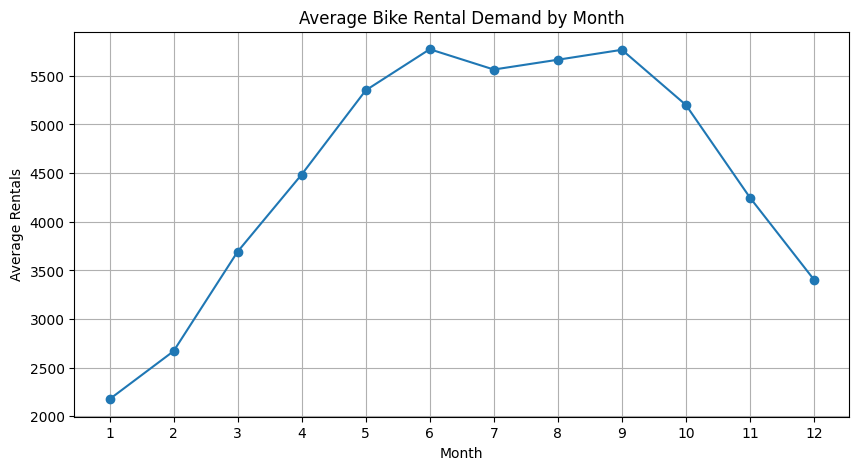

In [ ]:
monthly_demand = df.groupby("mnth")["cnt"].mean()

plt.figure(figsize=(10, 5))

plt.plot(
    monthly_demand.index,
    monthly_demand.values,
    marker="o"
)

plt.title("Average Bike Rental Demand by Month")
plt.xlabel("Month")
plt.ylabel("Average Rentals")

plt.xticks(range(1, 13))
plt.grid(True)

plt.show()

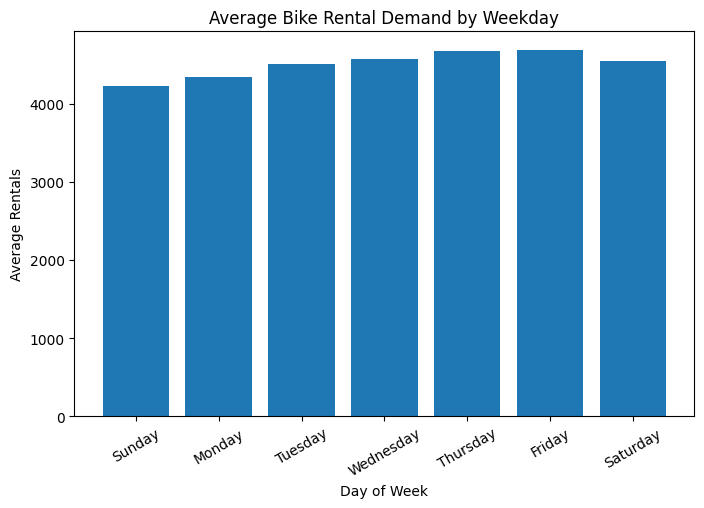

In [ ]:
weekday_demand = df.groupby("weekday")["cnt"].mean()

plt.figure(figsize=(8, 5))

plt.bar(
    ["Sunday", "Monday", "Tuesday", "Wednesday",
     "Thursday", "Friday", "Saturday"],
    weekday_demand.values
)

plt.title("Average Bike Rental Demand by Weekday")
plt.xlabel("Day of Week")
plt.ylabel("Average Rentals")

plt.xticks(rotation=30)
plt.show()

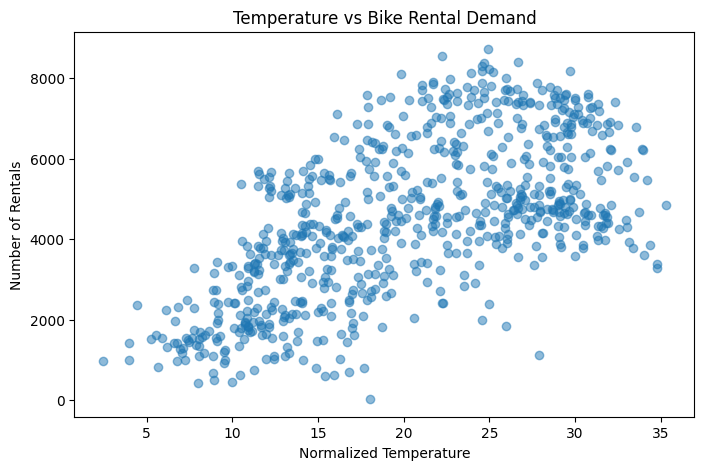

In [ ]:
plt.figure(figsize=(8, 5))

plt.scatter(df["temp"], df["cnt"], alpha=0.5)

plt.title("Temperature vs Bike Rental Demand")
plt.xlabel("Normalized Temperature")
plt.ylabel("Number of Rentals")

plt.show()

In [4]:
import pandas as pd
import zipfile
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Unzip the uploaded archive to extract day.csv
with zipfile.ZipFile('archive.zip', 'r') as zip_ref:
    zip_ref.extractall('.')

# Load dataset
df = pd.read_csv("day.csv")

# Remove unnecessary columns
# instant = ID
# casual and registered = data leakage because casual + registered = cnt
df = df.drop(columns=["instant", "casual", "registered"])

# Convert date column
df["dteday"] = pd.to_datetime(df["dteday"], dayfirst=True)

# Remove date column after conversion
df = df.drop(columns=["dteday"])

# Categorical columns
categorical_columns = [
    "season",
    "mnth",
    "weekday",
    "weathersit"
]

# One-hot encoding
df = pd.get_dummies(
    df,
    columns=categorical_columns,
    drop_first=True
)

# Target variable
y = df["cnt"]

# Features
X = df.drop(columns=["cnt"])

print("Features (X):")
print(X.columns.tolist())

print("\nTarget (y):")
print("cnt")

print("\nFeature shape:", X.shape)
print("Target shape:", y.shape)

Features (X):
['yr', 'holiday', 'workingday', 'temp', 'atemp', 'hum', 'windspeed', 'season_2', 'season_3', 'season_4', 'mnth_2', 'mnth_3', 'mnth_4', 'mnth_5', 'mnth_6', 'mnth_7', 'mnth_8', 'mnth_9', 'mnth_10', 'mnth_11', 'mnth_12', 'weekday_1', 'weekday_2', 'weekday_3', 'weekday_4', 'weekday_5', 'weekday_6', 'weathersit_2', 'weathersit_3']

Target (y):
cnt

Feature shape: (730, 29)
Target shape: (730,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training data:")
print("X_train:", X_train.shape)
print("y_train:", y_train.shape)

print("\nTesting data:")
print("X_test:", X_test.shape)
print("y_test:", y_test.shape)

Training data:
X_train: (584, 29)
y_train: (584,)

Testing data:
X_test: (146, 29)
y_test: (146,)


In [6]:
# Create the model
model = LinearRegression()

# Train the model
model.fit(X_train, y_train)

print("Linear Regression model trained successfully!")

Linear Regression model trained successfully!


In [7]:
# Make predictions on test data
y_pred = model.predict(X_test)

print("Sample Predictions:")
print(y_pred[:10])

Sample Predictions:
[6222.2680948  4268.73823003 3613.57089286 1861.85657582 7197.05425298
 5299.0500847  2620.70642239 2780.48738621 3708.32677149 3534.08188691]


In [8]:
comparison = pd.DataFrame({
    "Actual": y_test.values[:10],
    "Predicted": y_pred[:10]
})

display(comparison)

,Actual,Predicted
0,7460,6222.268095
1,4788,4268.738230
2,3331,3613.570893
3,3068,1861.856576
4,7338,7197.054253
5,5423,5299.050085
6,2046,2620.706422
7,2121,2780.487386
8,3409,3708.326771
9,3620,3534.081887


In [9]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

# Calculate evaluation metrics
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Model Evaluation Results")
print("------------------------")
print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R²  :", r2)

Model Evaluation Results
------------------------
MAE : 526.2752861605484
MSE : 471600.1210150734
RMSE: 686.7314766450373
R²  : 0.8622197210942278


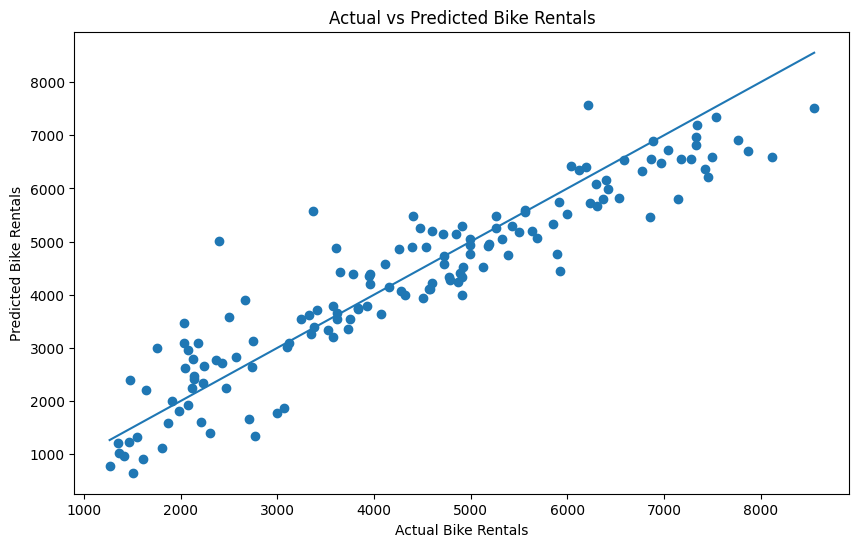

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.scatter(y_test, y_pred)

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Bike Rentals")
plt.ylabel("Predicted Bike Rentals")
plt.title("Actual vs Predicted Bike Rentals")

plt.show()

In [11]:
comparison = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": y_pred
})

comparison["Error"] = comparison["Actual"] - comparison["Predicted"]

display(comparison.head(10))

,Actual,Predicted,Error
0,7460,6222.268095,1237.731905
1,4788,4268.738230,519.261770
2,3331,3613.570893,-282.570893
3,3068,1861.856576,1206.143424
4,7338,7197.054253,140.945747
5,5423,5299.050085,123.949915
6,2046,2620.706422,-574.706422
7,2121,2780.487386,-659.487386
8,3409,3708.326771,-299.326771
9,3620,3534.081887,85.918113


In [12]:
def predict_bike_demand(
    season,
    yr,
    mnth,
    holiday,
    weekday,
    workingday,
    weathersit,
    temp,
    hum,
    windspeed
):
    # Create input DataFrame
    new_data = pd.DataFrame({
        "yr": [yr],
        "holiday": [holiday],
        "workingday": [workingday],
        "temp": [temp],
        "hum": [hum],
        "windspeed": [windspeed],
        "season": [season],
        "mnth": [mnth],
        "weekday": [weekday],
        "weathersit": [weathersit]
    })

    # Apply the SAME encoding used during training
    new_data = pd.get_dummies(
        new_data,
        columns=["season", "mnth", "weekday", "weathersit"],
        drop_first=True
    )

    # Make sure input has exactly the same columns as training data
    new_data = new_data.reindex(columns=X.columns, fill_value=0)

    # Convert to numeric
    new_data = new_data.astype(float)

    # Prediction
    prediction = model.predict(new_data)

    return max(0, round(prediction[0]))

In [13]:
prediction = predict_bike_demand(
    season=2,
    yr=1,
    mnth=6,
    holiday=0,
    weekday=2,
    workingday=1,
    weathersit=1,
    temp=0.70,
    hum=0.50,
    windspeed=0.15
)

print("Predicted Bike Demand:", prediction)

Predicted Bike Demand: 3707


In [14]:
!pip install -q gradio

In [15]:
import gradio as gr

def bike_prediction_app(
    season,
    year,
    month,
    holiday,
    weekday,
    workingday,
    weather,
    temperature,
    humidity,
    windspeed
):

    prediction = predict_bike_demand(
        season=int(season),
        yr=int(year),
        mnth=int(month),
        holiday=int(holiday),
        weekday=int(weekday),
        workingday=int(workingday),
        weathersit=int(weather),
        temp=float(temperature),
        hum=float(humidity),
        windspeed=float(windspeed)
    )

    return f"🚲 Predicted Bike Demand: {prediction} bikes"

demo = gr.Interface(
    fn=bike_prediction_app,

    inputs=[
        gr.Dropdown(
            choices=[1, 2, 3, 4],
            label="Season"
        ),

        gr.Dropdown(
            choices=[0, 1],
            label="Year"
        ),

        gr.Dropdown(
            choices=list(range(1, 13)),
            label="Month"
        ),

        gr.Dropdown(
            choices=[0, 1],
            label="Holiday"
        ),

        gr.Dropdown(
            choices=list(range(0, 7)),
            label="Weekday"
        ),

        gr.Dropdown(
            choices=[0, 1],
            label="Working Day"
        ),

        gr.Dropdown(
            choices=[1, 2, 3, 4],
            label="Weather Situation"
        ),

        gr.Slider(
            minimum=0,
            maximum=1,
            value=0.5,
            step=0.01,
            label="Temperature"
        ),

        gr.Slider(
            minimum=0,
            maximum=1,
            value=0.5,
            step=0.01,
            label="Humidity"
        ),

        gr.Slider(
            minimum=0,
            maximum=1,
            value=0.2,
            step=0.01,
            label="Windspeed"
        )
    ],

    outputs=gr.Textbox(
        label="Prediction"
    ),

    title="🚲 Bike Rental Demand Predictor",
    description="Enter the daily weather and time conditions to predict bike rental demand."
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://55ad93289304ba045a.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


In [16]:
print("========== FINAL PROJECT RESULTS ==========")

print(f"MAE  : {mae:.2f}")
print(f"MSE  : {mse:.2f}")
print(f"RMSE : {rmse:.2f}")
print(f"R²   : {r2:.4f}")

print("\nModel: Linear Regression")
print("Target: cnt (Total Bike Rentals)")
print("Dataset: UCI Bike Sharing - day.csv")

========== FINAL PROJECT RESULTS ==========
MAE  : 526.28
MSE  : 471600.12
RMSE : 686.73
R²   : 0.8622

Model: Linear Regression
Target: cnt (Total Bike Rentals)
Dataset: UCI Bike Sharing - day.csv


In [18]:
import gradio as gr
import pandas as pd
import joblib

# Save trained model and training columns for later loading
joblib.dump(model, "bike_rental_model.pkl")
joblib.dump(X.columns, "training_columns.pkl")

# Load trained model
model = joblib.load("bike_rental_model.pkl")


def predict_bike_demand(
    season,
    year,
    month,
    holiday,
    weekday,
    workingday,
    weather,
    temperature,
    humidity,
    windspeed
):

    new_data = pd.DataFrame({
        "yr": [int(year)],
        "holiday": [int(holiday)],
        "workingday": [int(workingday)],
        "temp": [float(temperature)],
        "hum": [float(humidity)],
        "windspeed": [float(windspeed)],
        "season": [int(season)],
        "mnth": [int(month)],
        "weekday": [int(weekday)],
        "weathersit": [int(weather)]
    })

    # Apply the same encoding used during training
    new_data = pd.get_dummies(
        new_data,
        columns=[
            "season",
            "mnth",
            "weekday",
            "weathersit"
        ],
        drop_first=True
    )

    # Match training columns
    # This requires the training column list to be saved.
    training_columns = joblib.load("training_columns.pkl")

    new_data = new_data.reindex(
        columns=training_columns,
        fill_value=0
    )

    new_data = new_data.astype(float)

    prediction = model.predict(new_data)[0]

    prediction = max(0, round(prediction))

    return f"🚲 Predicted Bike Demand: {prediction} bikes"


demo = gr.Interface(
    fn=predict_bike_demand,

    inputs=[
        gr.Dropdown([1, 2, 3, 4], label="Season"),
        gr.Dropdown([0, 1], label="Year"),
        gr.Dropdown(list(range(1, 13)), label="Month"),
        gr.Dropdown([0, 1], label="Holiday"),
        gr.Dropdown(list(range(7)), label="Weekday"),
        gr.Dropdown([0, 1], label="Working Day"),
        gr.Dropdown([1, 2, 3, 4], label="Weather Situation"),

        gr.Slider(
            0, 1,
            value=0.5,
            step=0.01,
            label="Temperature"
        ),

        gr.Slider(
            0, 1,
            value=0.5,
            step=0.01,
            label="Humidity"
        ),

        gr.Slider(
            0, 1,
            value=0.2,
            step=0.01,
            label="Windspeed"
        )
    ],

    outputs=gr.Textbox(label="Prediction"),

    title="🚲 Bike Rental Demand Predictor",

    description=(
        "Enter daily weather and time conditions "
        "to predict the number of bikes likely to be rented."
    )
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9f92756e2ae37cacd4.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
